In [1]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [ ]:
titolo = "Fit Lineare Phi"
xlabel = "f (Hz)"
ylabel = "Phi (rad)"

file_input = "dati_phi_lineari.csv"

In [ ]:
file_output1 = "regressione.txt"
file_output2 = "residui.txt"
file_output3 = "chi.txt"
grafico_output1 = "regressione.jpg"
grafico_output2 = "residui.jpg"
grafico_output3 = "chi.jpg"

cartella = "Analisi_phi"

In [4]:
import os
os.makedirs(cartella, exist_ok=True)

# 1. Lettura

In [5]:
data = f.csv_to_dict(file_input)

xdata = np.array([data["x"],data["sx"]])
ydata = np.array([data["y"],data["sy"]])

# 2. Analisi

In [6]:
def modello(par, x):
    return par[0] + par[1]*x

param_labels = ['a','b']

Regressione

In [7]:
anal = f.fit(xdata,ydata,modello,[0,1])

f.inizializza_output(cartella + "/" + file_output1)
gf.salva_analisi(anal, param_labels, cartella + "/" + file_output1)

Residui

In [8]:
f.inizializza_output(cartella + "/" + file_output2)
res = f.residui(xdata,ydata,anal[:,0],modello,cartella + "/" + file_output2,titolo)

Chi Quadro

In [9]:
f.inizializza_output(cartella + "/" + file_output3)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,cartella + "/" + file_output3,titolo)

# 3. Grafici

Regressione

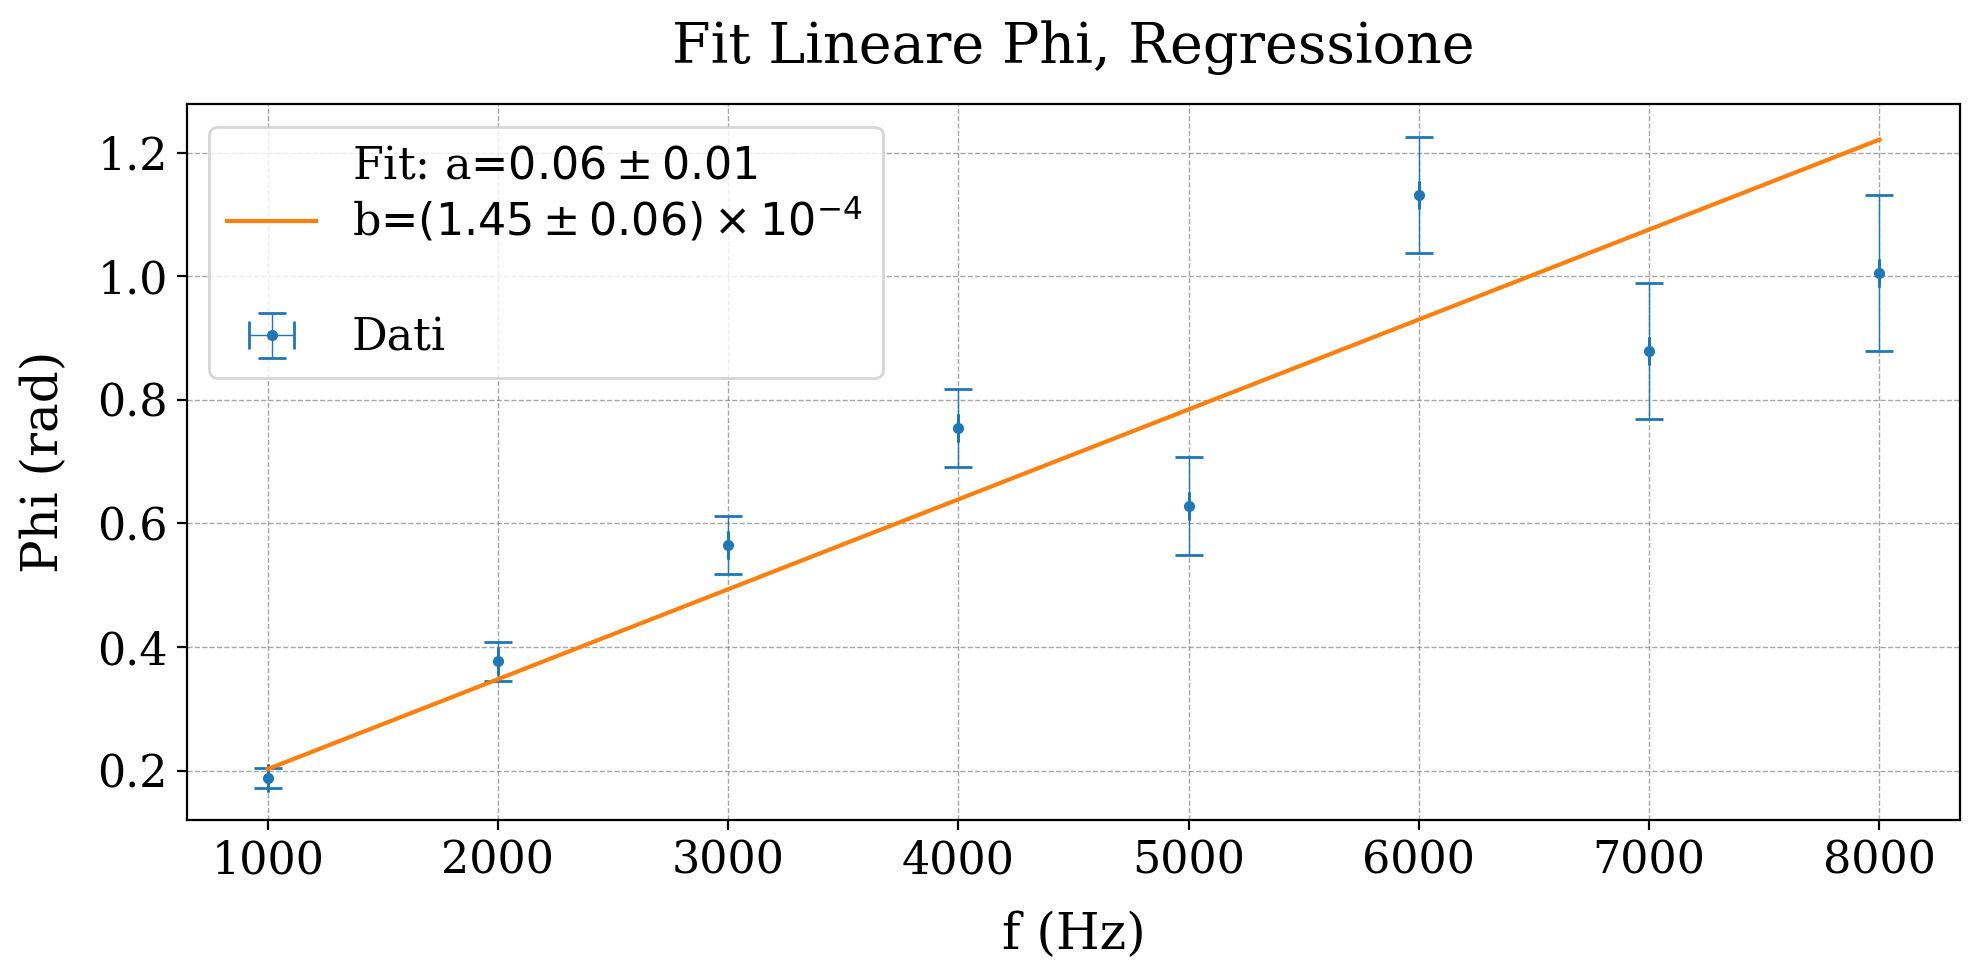

In [10]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,cartella + "/" + grafico_output1)

Residui

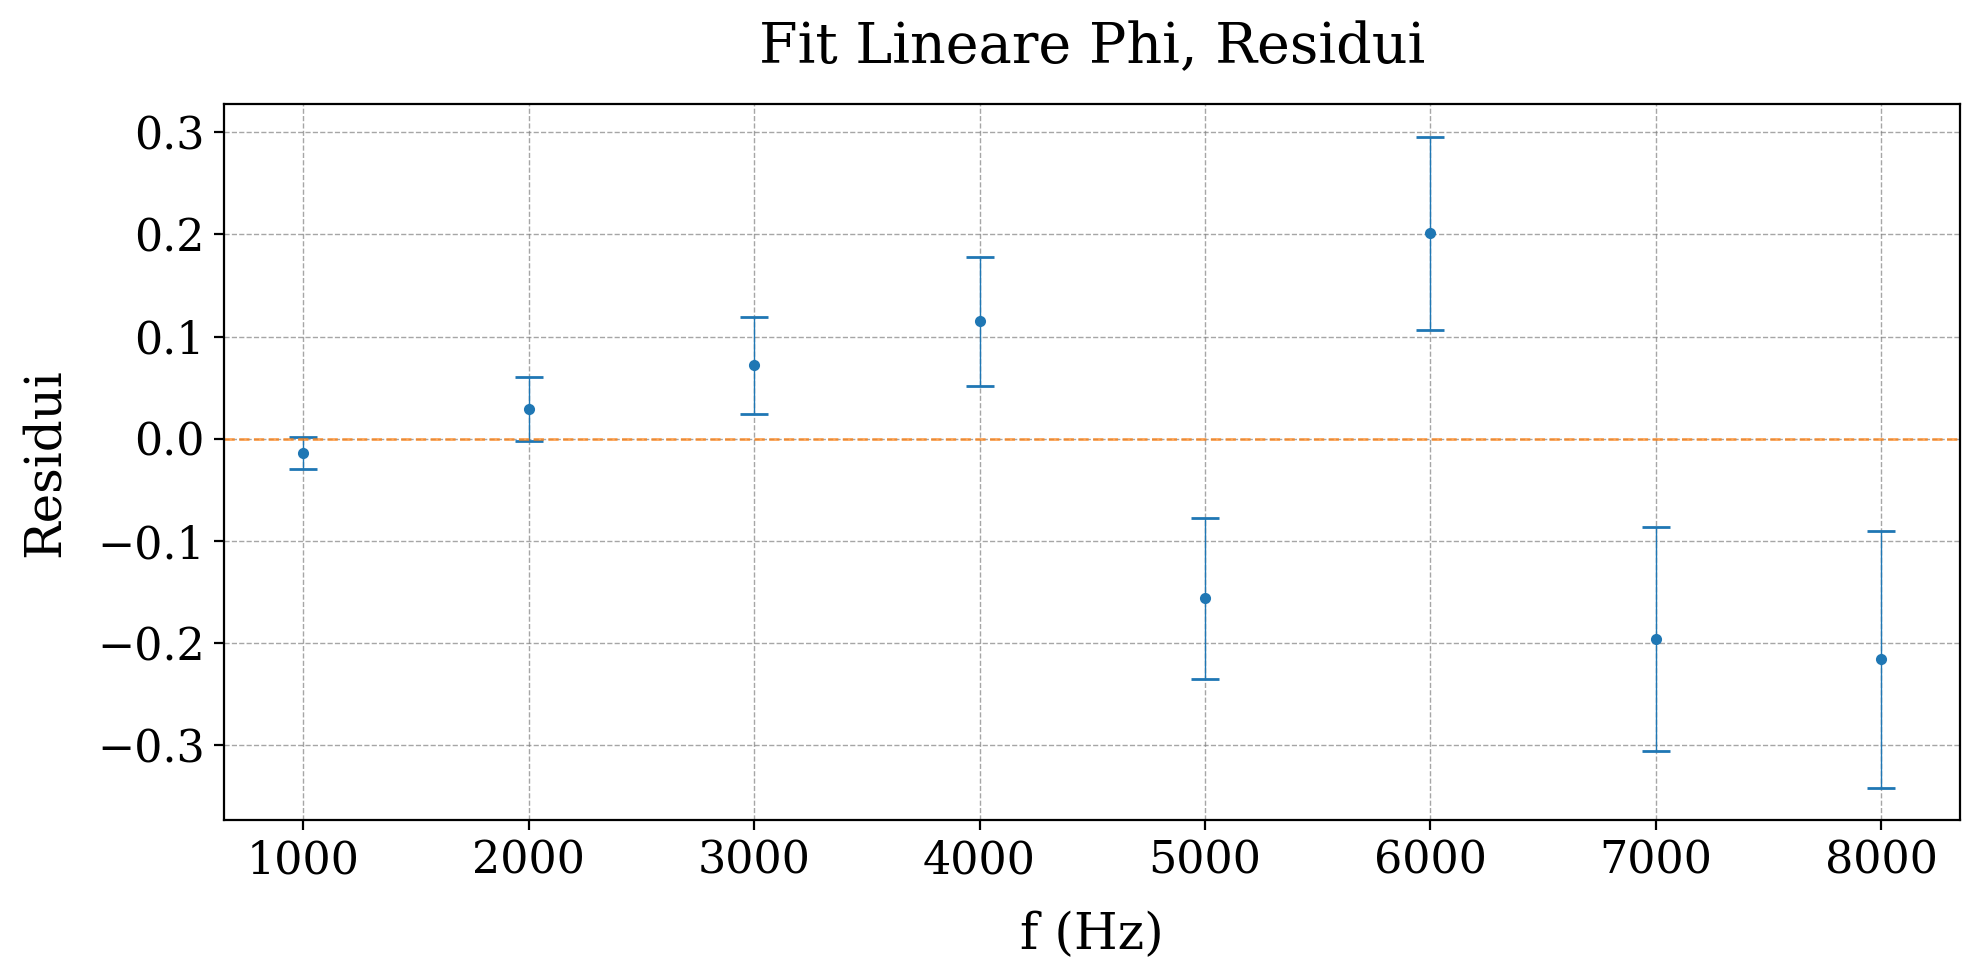

In [11]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig, cartella + "/" + grafico_output2)

Chi Quadro

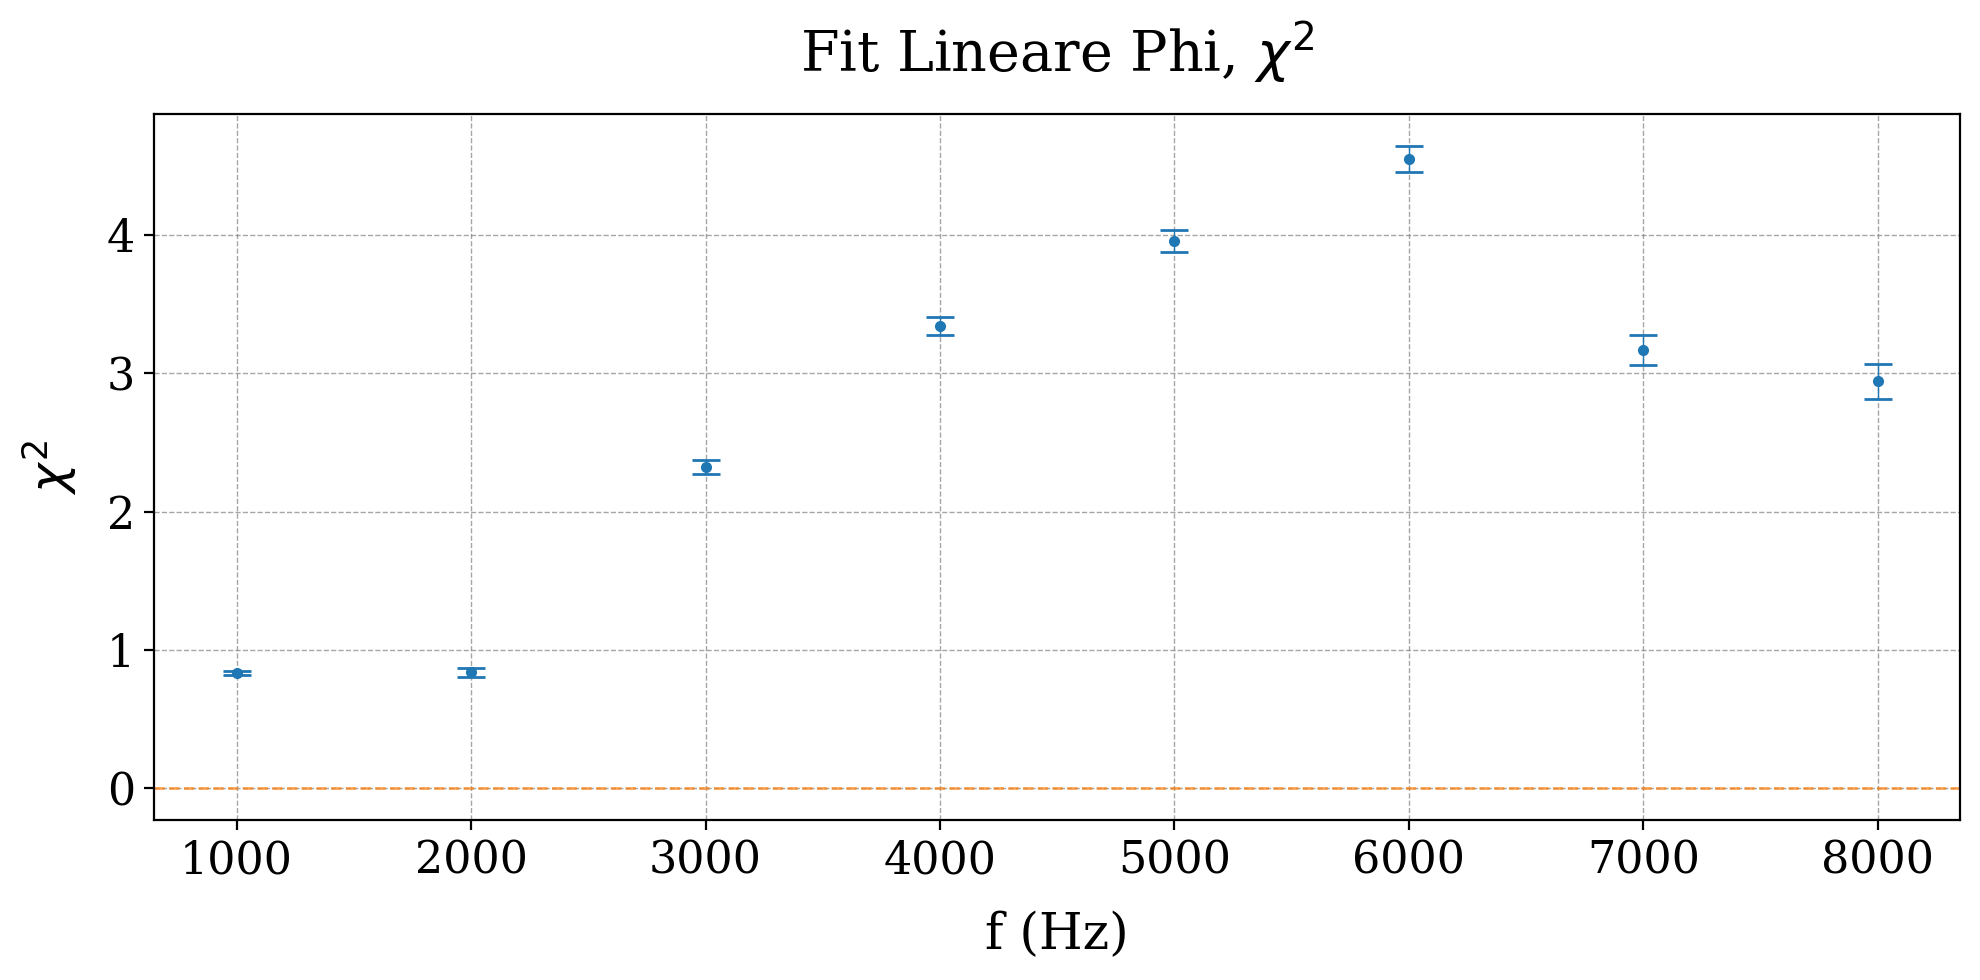

In [12]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel=r"$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,cartella + "/" + grafico_output3)